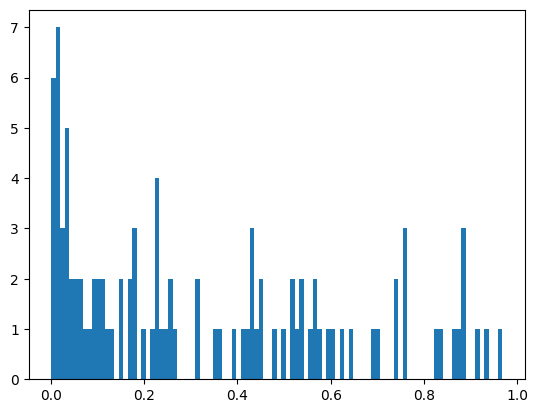

In [12]:
import numpy as np
import matplotlib.pyplot as plt

K = 100

p = 2
correspondences = np.random.rand(K)**p
plt.hist(correspondences,bins=100);

correspondences_normalized = correspondences / correspondences.sum()


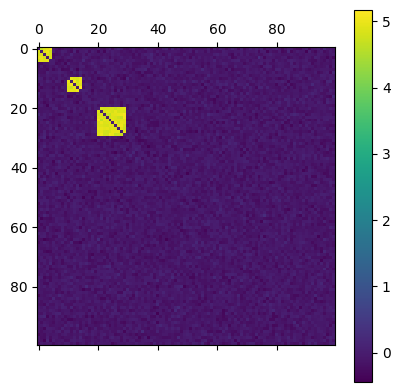

In [28]:
alpha = 0.
excitatory = 5.
J = (np.random.randn(K,K) - 1) * 0.1
J[:5,:5] += excitatory
J[10:15,10:15] += excitatory
J[20:30,20:30] += excitatory

J[np.arange(K),np.arange(K)] = alpha
plt.matshow(J)
plt.colorbar()



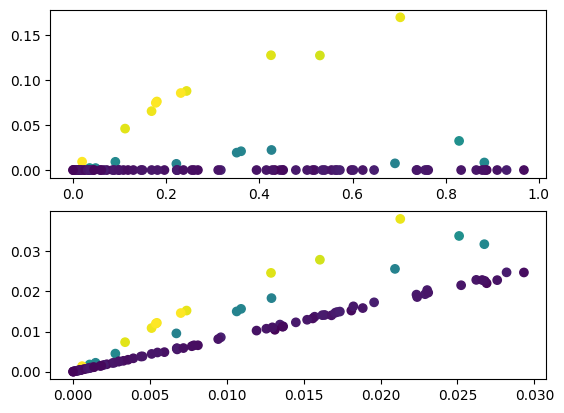

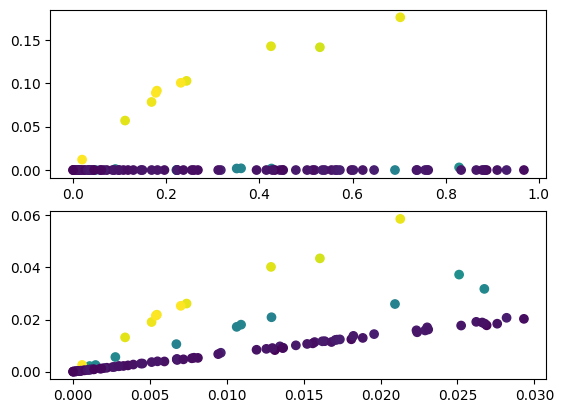

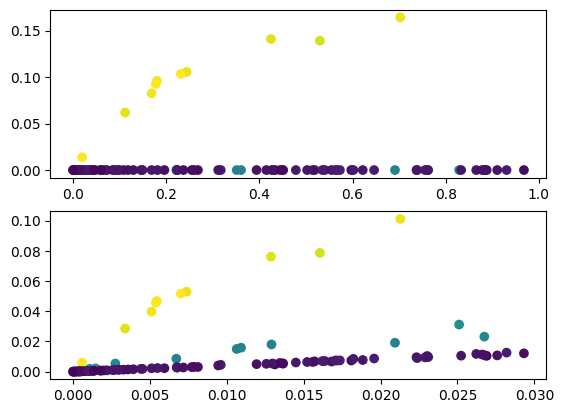

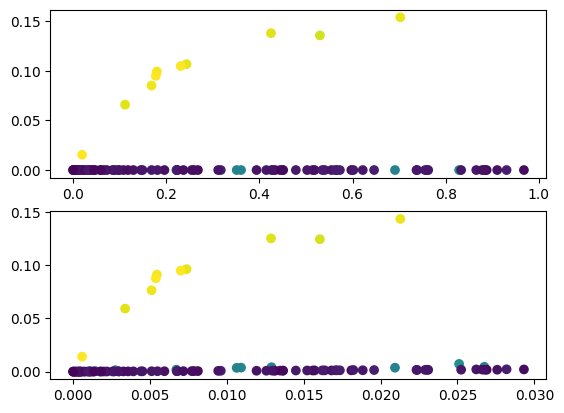

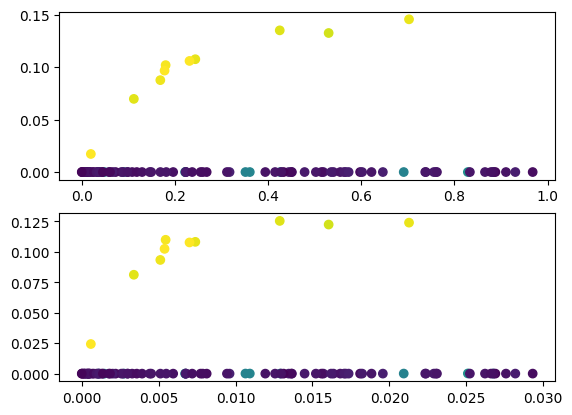

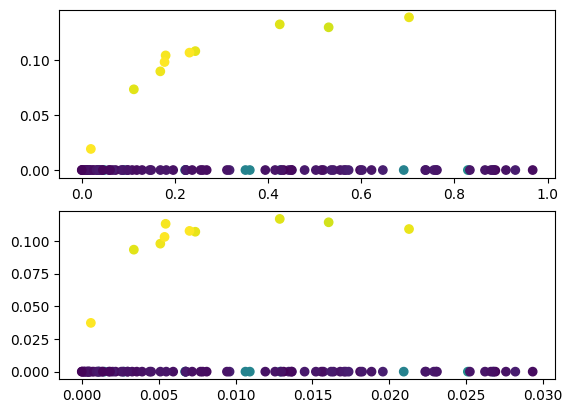

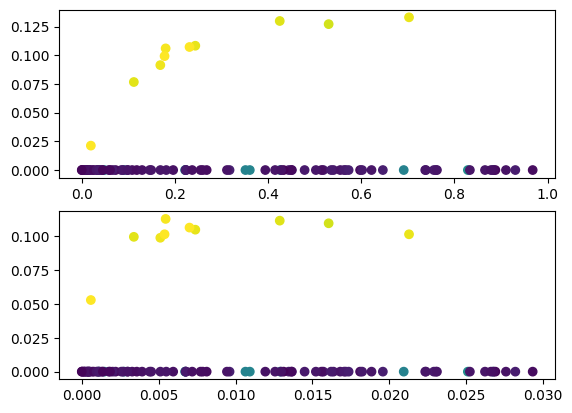

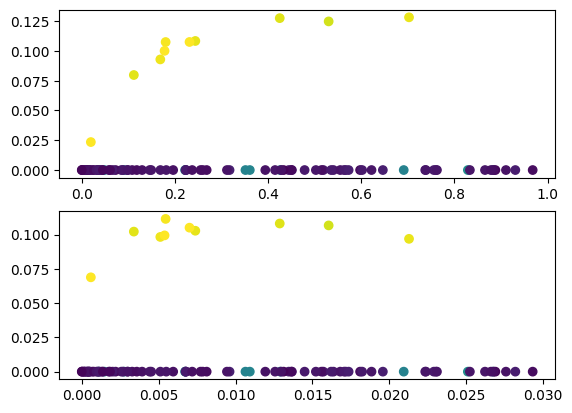

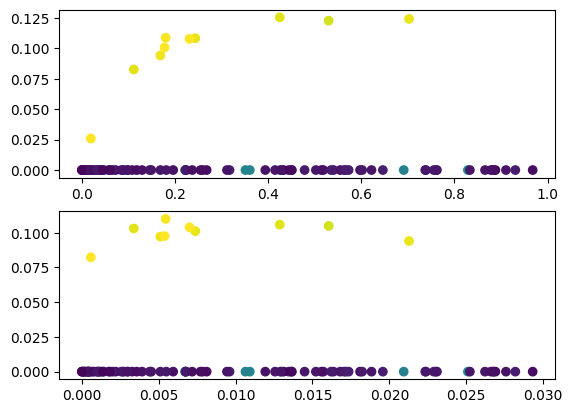

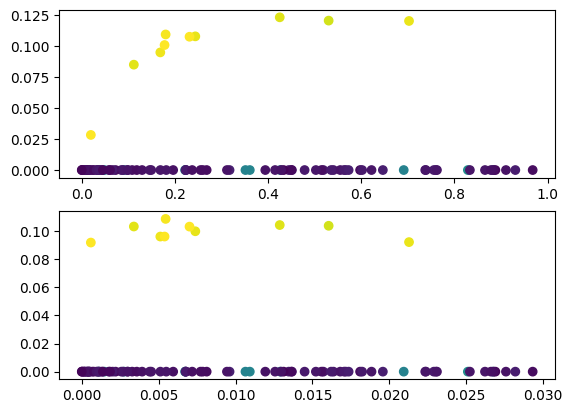

In [29]:
def update_1(correspondences,J):
    tmp = correspondences * np.maximum( 0, J @ correspondences)
    return tmp / tmp.sum()

def update_2(correspondences,J):
    messages = J @ correspondences
    messages -= messages.max()
    tmp = correspondences * np.exp(messages)
    new_correspondences = tmp/tmp.sum()
    return new_correspondences


degree = J.sum(1)

all_updates2 = [correspondences_normalized]

updated_1 = update_1(correspondences,J) 
updated_2 = update_2(correspondences_normalized,J)

all_updates2.append(updated_2)

for i in range(10):
    updated_1 = update_1(updated_1,J) 
    updated_2 = update_2(updated_2,J)
    fig,ax=plt.subplots(2,1)
    ax[0].scatter( correspondences, updated_1,c=degree)
    ax[1].scatter( correspondences_normalized, updated_2,c=degree); 
    plt.show()
    all_updates2.append(updated_2)
    

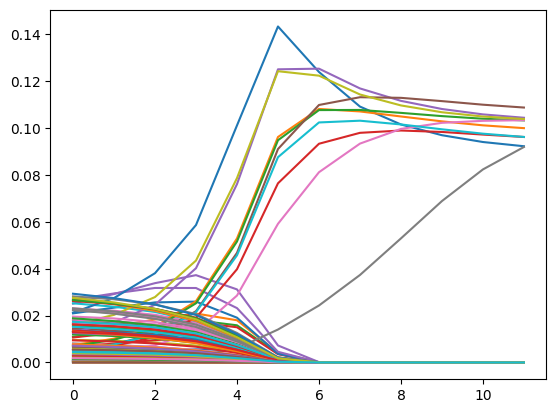

In [30]:
plt.plot(np.array(all_updates2));

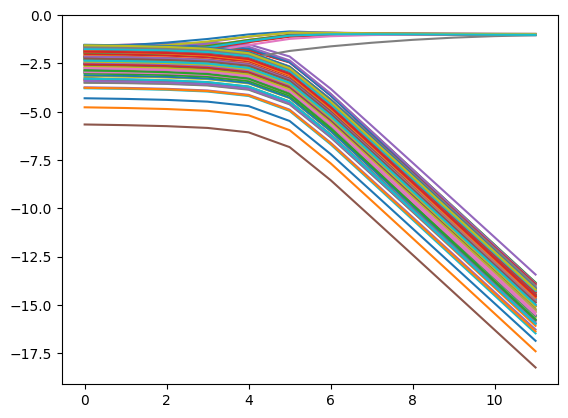

In [31]:
plt.plot(np.log10(np.array(all_updates2)));